# Heatmap Annotations

Heatmap annotations are important components that show additional information associated with rows or columns. **complexheatmap** provides very flexible support for annotations via `HeatmapAnnotation`, `rowAnnotation`, and `columnAnnotation`, plus a suite of `anno_*` functions.

Annotations can be placed on all four sides of the heatmap: `top_annotation`, `bottom_annotation`, `left_annotation`, and `right_annotation`.

In [1]:
import numpy as np
import pandas as pd
import complexheatmap as ch
from complexheatmap import (
    Heatmap, HeatmapAnnotation, rowAnnotation, columnAnnotation,
    anno_barplot, anno_boxplot, anno_points, anno_lines,
    anno_histogram, anno_density, anno_text, anno_block,
    anno_empty, anno_simple, color_ramp2
)
import grid_py as gp

In [2]:
np.random.seed(123)
mat = np.random.randn(10, 10)
n = 10

## Simple Annotation

A "simple annotation" is a heatmap-like color strip where values are mapped to colors. Just pass a numeric or categorical vector as a keyword argument to `HeatmapAnnotation`.

In [3]:
# Numeric simple annotation
ha = HeatmapAnnotation(foo=np.arange(1, 11))
print(f"nobs: {ha.nobs}, names: {ha.names}")

nobs: 10, names: ['foo']


In [4]:
# Categorical simple annotation
ha = HeatmapAnnotation(
    group=np.array(["A", "B"] * 5)
)
print(f"nobs: {ha.nobs}, names: {ha.names}")

nobs: 10, names: ['group']


### Controlling colors

For continuous annotations, provide a `color_ramp2` function. For discrete annotations, provide a dict mapping levels to colors. The `col` argument is a dict keyed by annotation name.

In [5]:
col_fun = color_ramp2([0, 5, 10], ["blue", "white", "red"])

ha = HeatmapAnnotation(
    foo=np.arange(1, 11),
    bar=np.random.choice(["a", "b", "c"], size=10),
    col={"foo": col_fun,
         "bar": {"a": "red", "b": "green", "c": "blue"}}
)
print(f"Annotation names: {ha.names}")

Annotation names: ['foo', 'bar']


## Complex Annotations: `anno_*` Functions

Beyond simple color strips, complexheatmap provides many annotation types.

### Barplot annotation

In [6]:
ha_bar = HeatmapAnnotation(
    bar=anno_barplot(np.random.rand(n))
)
print(f"nobs: {ha_bar.nobs}")

nobs: 10


### Boxplot annotation

In [7]:
ha_box = HeatmapAnnotation(
    box=anno_boxplot(np.random.randn(n, 5))
)
print(f"nobs: {ha_box.nobs}")

nobs: 10


### Points annotation

In [8]:
ha_pts = HeatmapAnnotation(
    pts=anno_points(np.random.randn(n))
)
print(f"nobs: {ha_pts.nobs}")

nobs: 10


### Lines annotation

In [9]:
ha_lines = HeatmapAnnotation(
    lines=anno_lines(np.random.randn(n))
)
print(f"nobs: {ha_lines.nobs}")

nobs: 10


### Histogram annotation

For each row/column, a histogram is drawn from a vector of values. Input is a matrix where each row is one observation.

In [10]:
ha_hist = HeatmapAnnotation(
    hist=anno_histogram(np.random.randn(n, 50))
)

### Density annotation

In [11]:
ha_dens = HeatmapAnnotation(
    dens=anno_density(np.random.randn(n, 50))
)

### Text annotation

In [12]:
labels = [f"lab{i}" for i in range(n)]
ha_txt = HeatmapAnnotation(
    txt=anno_text(labels)
)

### Block annotation

`anno_block` is useful with split heatmaps -- it fills colored rectangles for each slice.

In [13]:
ha_block = HeatmapAnnotation(
    block=anno_block(gp={"fill": ["red", "blue"]})
)

### Empty annotation

`anno_empty` reserves space that can be filled later using decoration functions.

In [14]:
ha_empty = HeatmapAnnotation(
    empty=anno_empty()
)

## Multiple Annotations in One Object

You can combine several annotations into one `HeatmapAnnotation` object.

In [15]:
ha_multi = HeatmapAnnotation(
    group=np.array(["A", "B"] * 5),
    bar=anno_barplot(np.random.rand(n)),
    pts=anno_points(np.random.randn(n)),
)
print(f"Number of annotations: {len(ha_multi.anno_list)}")
print(f"Names: {ha_multi.names}")

Number of annotations: 3
Names: ['group', 'bar', 'pts']


## Integrating Annotations with a Heatmap

Pass `HeatmapAnnotation` objects to `top_annotation`, `bottom_annotation`, `left_annotation`, or `right_annotation`.

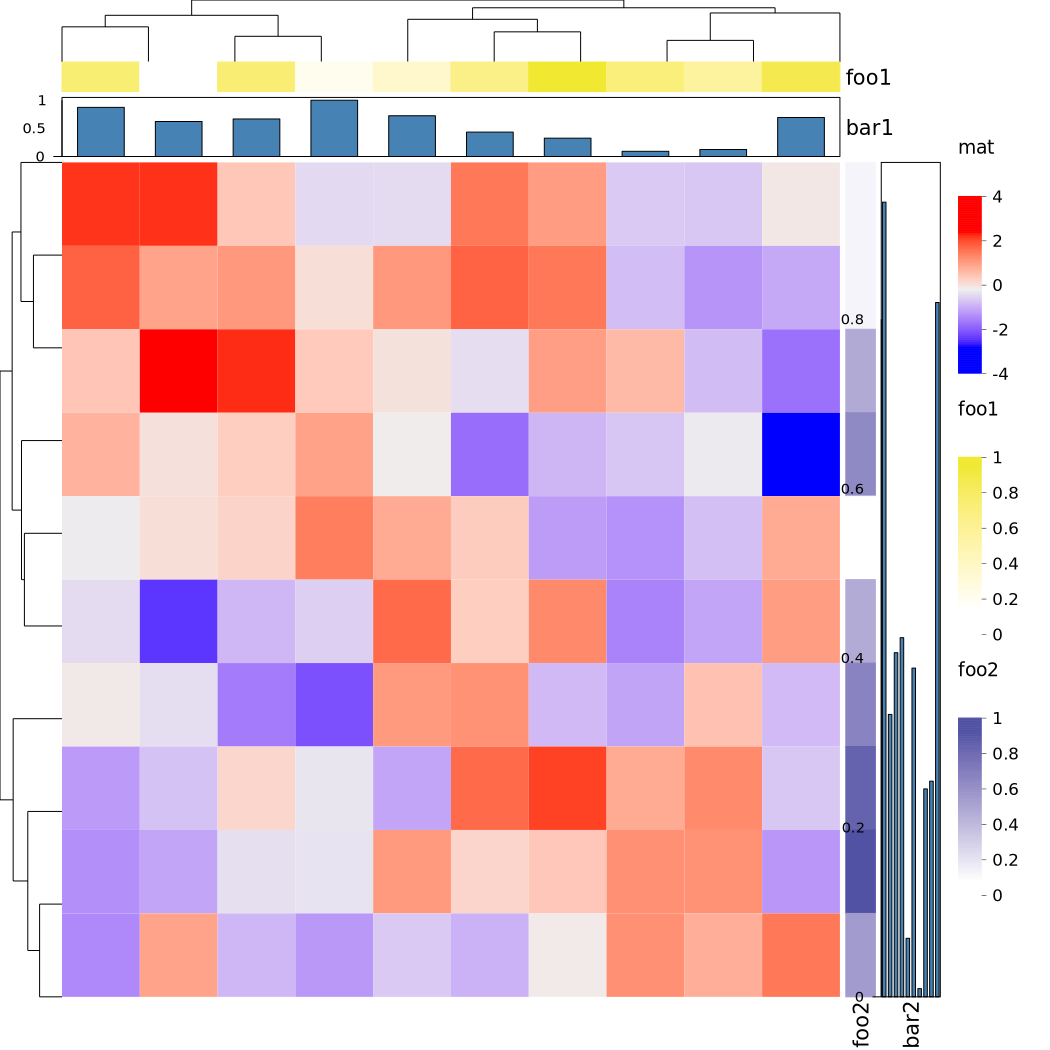

In [16]:
column_ha = HeatmapAnnotation(
    foo1=np.random.rand(n),
    bar1=anno_barplot(np.random.rand(n))
)
row_ha = rowAnnotation(
    foo2=np.random.rand(n),
    bar2=anno_barplot(np.random.rand(n))
)

ht = Heatmap(mat, name="mat",
             top_annotation=column_ha,
             right_annotation=row_ha)
# ht.draw()
ht.draw()

Annotations can also be placed at the bottom and left:

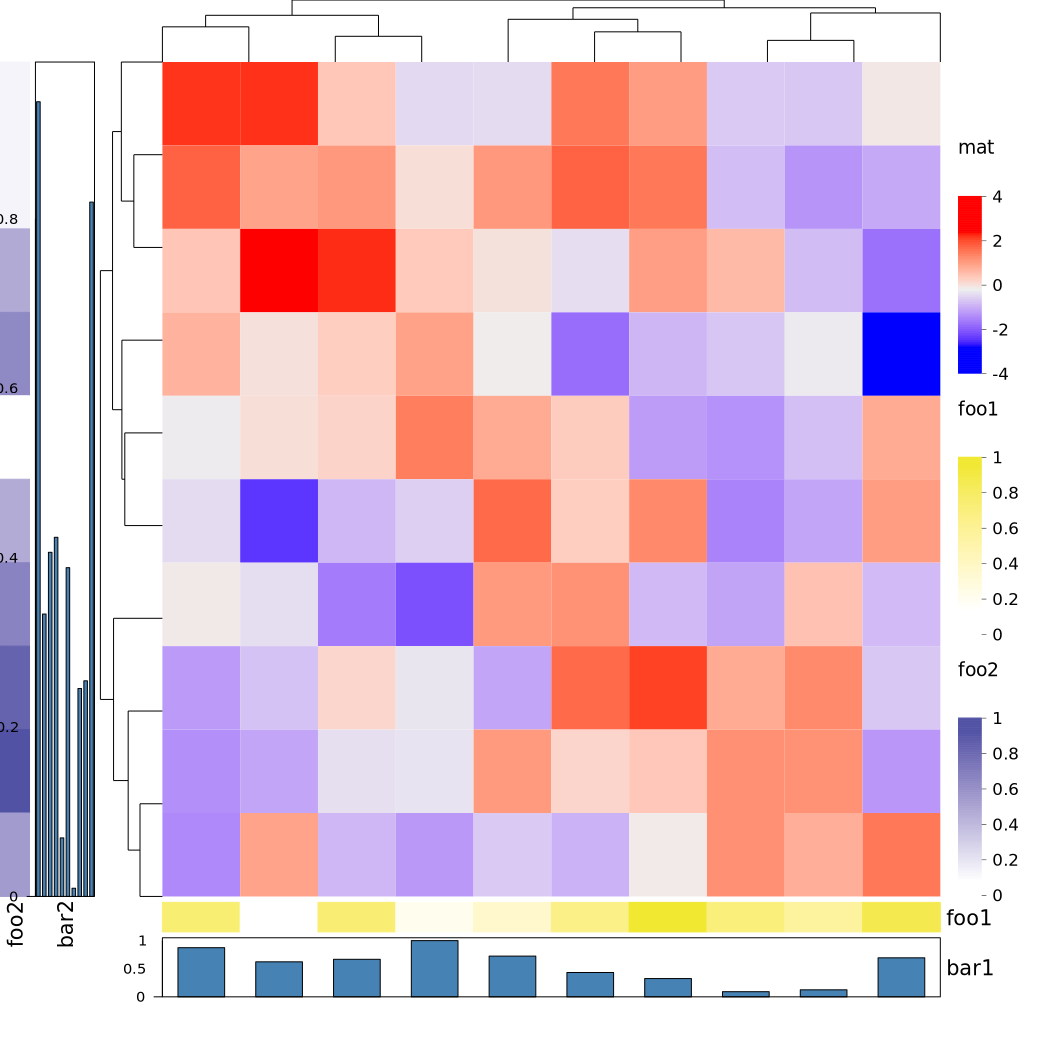

In [17]:
ht = Heatmap(mat, name="mat",
             bottom_annotation=column_ha,
             left_annotation=row_ha)
ht.draw()

## `rowAnnotation` and `columnAnnotation` helpers

`rowAnnotation(...)` is identical to `HeatmapAnnotation(..., which="row")`. Similarly, `columnAnnotation(...)` is identical to `HeatmapAnnotation(..., which="column")`.

In [18]:
ra = rowAnnotation(foo=np.random.randn(n))
print(f"which: {ra.which}")

ca = columnAnnotation(foo=np.random.randn(n))
print(f"which: {ca.which}")

which: row
which: column


## Annotation with Color Mapping

When you put a simple annotation into a heatmap, its legend is automatically generated. The colors come from the `col` argument in `HeatmapAnnotation`.

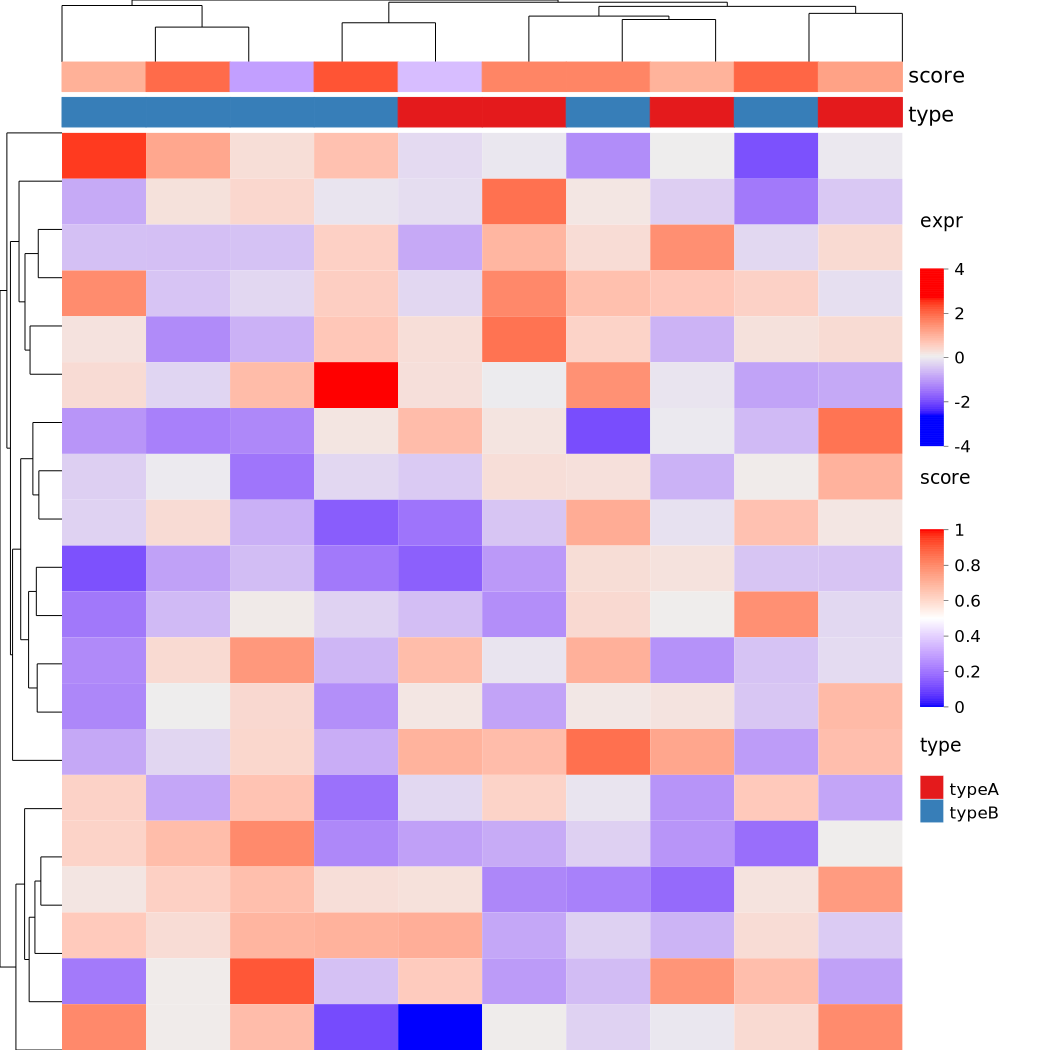

In [19]:
np.random.seed(42)
mat20 = np.random.randn(20, 10)

ha_top = HeatmapAnnotation(
    score=np.random.rand(10),
    type=np.random.choice(["typeA", "typeB"], size=10),
    col={
        "score": color_ramp2([0, 0.5, 1], ["blue", "white", "red"]),
        "type": {"typeA": "#E41A1C", "typeB": "#377EB8"}
    }
)

ht = Heatmap(mat20, name="expr", top_annotation=ha_top)
ht.draw()

## Composite Annotations with Split Heatmaps

When the heatmap is split, annotations are automatically split accordingly.

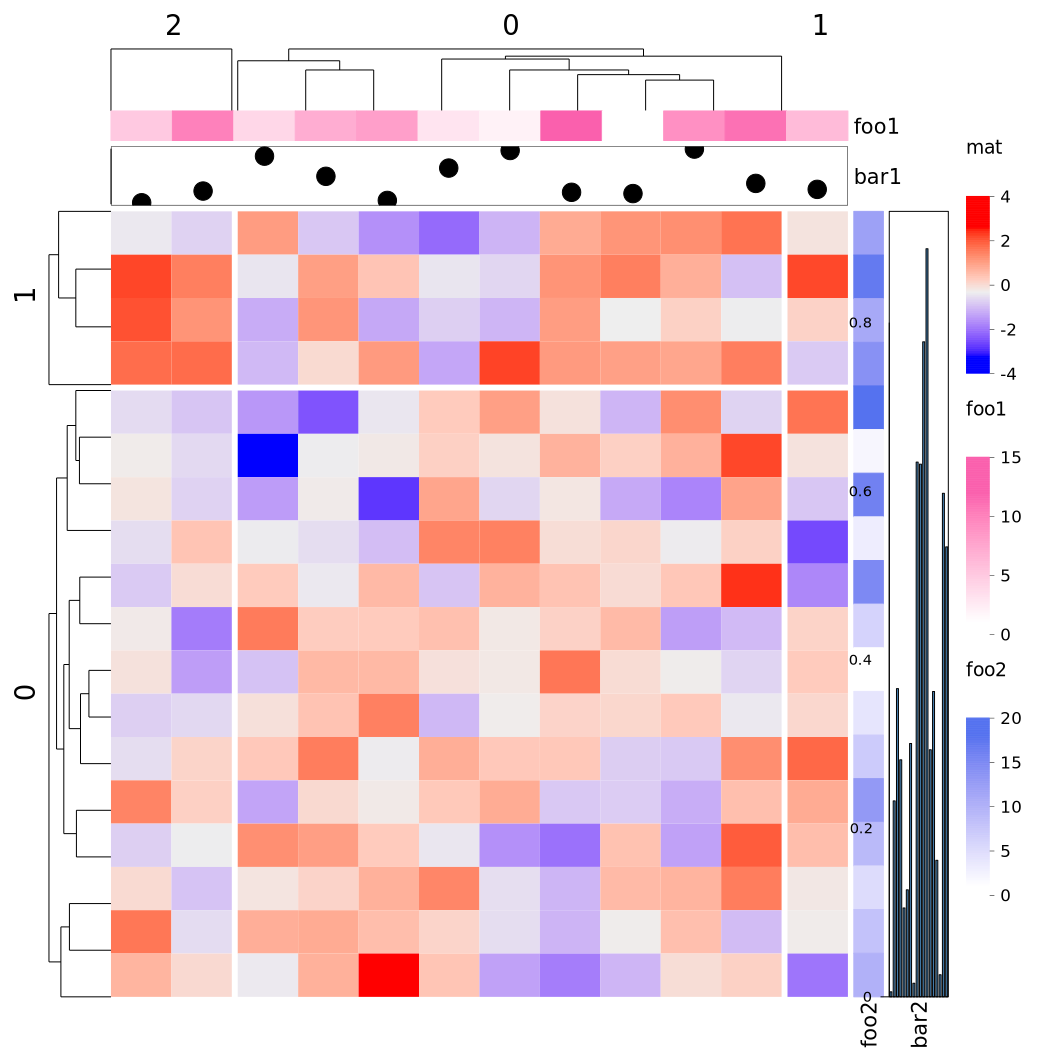

In [20]:
np.random.seed(123)
mat18 = np.random.randn(18, 12)

ht = Heatmap(mat18, name="mat",
    row_km=2, column_km=3,
    top_annotation=HeatmapAnnotation(
        foo1=np.arange(1, 13),
        bar1=anno_points(np.random.rand(12))
    ),
    right_annotation=rowAnnotation(
        foo2=np.arange(18, 0, -1),
        bar2=anno_barplot(np.random.rand(18))
    )
)
ht.draw()

## Summary

This tutorial covered:

- Simple annotations (numeric and categorical vectors)
- Color mapping for annotations via the `col` argument
- Complex annotation types: `anno_barplot`, `anno_boxplot`, `anno_points`, `anno_lines`, `anno_histogram`, `anno_density`, `anno_text`, `anno_block`, `anno_empty`
- Combining multiple annotations in `HeatmapAnnotation`
- Integrating annotations with heatmaps via `top_annotation`, `bottom_annotation`, `left_annotation`, `right_annotation`
- `rowAnnotation` and `columnAnnotation` helper functions
- Annotations in split heatmaps